In [2]:
from google.colab import drive
drive.mount("/content/gdrive")

import os
os.chdir('/content/gdrive/MyDrive/ViralMut/')

Mounted at /content/gdrive


In [3]:
import warnings

warnings.filterwarnings('ignore')

!mkdir -p ~/.fonts
!cp arial.ttf ~/.fonts/
!fc-cache -fv

/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 2 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/var/cache/fontconfig: cleaning cache directory
/root/.cache/fontconfig: not cleaning non-existent cache directory
/root/.fontconfig: not cleaning non-existent cache directory
fc-cache: succeeded


In [4]:
from matplotlib import font_manager as fm

font_dir = os.path.join(os.environ['HOME'], '.fonts')
os.makedirs(font_dir, exist_ok=True)
font_name = 'arial.ttf'
font_path = os.path.join(font_dir, font_name)
fm.fontManager.addfont(font_path)

!cp {font_name} {font_dir}

## BRCA1

In [5]:
import pandas as pd
import os

def load_gene_data(gene_name, base_path='./ClinMAVE/LLR'):

    suffixes = [
        f'missense_{gene_name}_cri_normal_LLR_results.csv',
        f'missense_{gene_name}_cri_normal_LLR_CaLM_results.csv',
        f'missense_{gene_name}_cri_lof_LLR_results.csv',
        f'missense_{gene_name}_cri_lof_LLR_CaLM_results.csv',
        f'missense_{gene_name}_dms_normal_LLR_results.csv',
        f'missense_{gene_name}_dms_normal_LLR_CaLM_results.csv',
        f'missense_{gene_name}_dms_lof_LLR_results.csv',
        f'missense_{gene_name}_dms_lof_LLR_CaLM_results.csv'
    ]

    results = []
    for s in suffixes:
        path = os.path.join(base_path, s)
        if os.path.exists(path):
            results.append(pd.read_csv(path))
        else:
            print(f"Warning: {s} not found.")
            results.append(None)

    return tuple(results)

(normal_prot_cri, normal_gene_cri,
 lof_prot_cri, lof_gene_cri,
 normal_prot_dms, normal_gene_dms,
 lof_prot_dms, lof_gene_dms) = load_gene_data('brca1')

In [6]:
def add_suffix(df, suffix):
    df = df.copy()
    df.columns = [f"{col}_{suffix}" for col in df.columns]
    return df

normal_prot_dms = add_suffix(normal_prot_dms, 'prot')
normal_gene_dms = add_suffix(normal_gene_dms, 'gene')
lof_prot_dms = add_suffix(lof_prot_dms, 'prot')
lof_gene_dms = add_suffix(lof_gene_dms, 'gene')
normal_prot_cri = add_suffix(normal_prot_cri, 'prot')
normal_gene_cri = add_suffix(normal_gene_cri, 'gene')
lof_prot_cri = add_suffix(lof_prot_cri, 'prot')
lof_gene_cri = add_suffix(lof_gene_cri, 'gene')

In [7]:
!pip install bayesian-optimization

In [8]:
import numpy as np
from sklearn.metrics import roc_auc_score
from bayes_opt import BayesianOptimization

def prepare_matched_data(normal_prot, normal_gene, lof_prot, lof_gene):
    """Merge protein and codon LLRs, then find overlapping variants."""
    normal = normal_prot.merge(normal_gene,
                                left_on='Identifier_prot',
                                right_on='Identifier_gene')
    normal['label'] = 0

    lof = lof_prot.merge(lof_gene,
                          left_on='Identifier_prot',
                          right_on='Identifier_gene')
    lof['label'] = 1

    df = pd.concat([normal, lof], ignore_index=True)
    return df

def optimize_weight(df, n_folds=10, random_state=16):

    """10-fold CV with Bayesian optimization to find optimal CaLM weight."""

    from sklearn.model_selection import KFold

    kf = KFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    fold_weights = []
    fold_aucs = []

    for train_idx, test_idx in kf.split(df):
        train = df.iloc[train_idx]
        test = df.iloc[test_idx]

        def objective(w):
            scores = w * train['LLR_gene'] + (1 - w) * train['LLR_prot']
            try:
                return roc_auc_score(train['label'], -scores)
            except:
                return 0.5

        optimizer = BayesianOptimization(
            f=objective,
            pbounds={'w': (0, 1)},
            random_state=random_state,
            verbose=0
        )
        optimizer.maximize(init_points=10, n_iter=20)

        best_w = optimizer.max['params']['w']
        fold_weights.append(best_w)

        test_scores = best_w * test['LLR_gene'] + (1 - best_w) * test['LLR_prot']
        try:
            auc = roc_auc_score(test['label'], -test_scores)
        except:
            auc = np.nan
        fold_aucs.append(auc)

    return fold_weights, fold_aucs

In [9]:
df_dms = prepare_matched_data(normal_prot_dms, normal_gene_dms, lof_prot_dms, lof_gene_dms)
df_cri = prepare_matched_data(normal_prot_cri, normal_gene_cri, lof_prot_cri, lof_gene_cri)

print(f"DMS: {len(df_dms)} variants (Normal: {(df_dms['label']==0).sum()}, LoF: {(df_dms['label']==1).sum()})")
print(f"CBGE: {len(df_cri)} variants (Normal: {(df_cri['label']==0).sum()}, LoF: {(df_cri['label']==1).sum()})")

dms_weights, dms_aucs = optimize_weight(df_dms)
cri_weights, cri_aucs = optimize_weight(df_cri)

print(f"\nDMS: w = {np.mean(dms_weights):.3f} ± {np.std(dms_weights):.3f}")
print(f"CBGE: w = {np.mean(cri_weights):.3f} ± {np.std(cri_weights):.3f}")

from scipy.stats import wilcoxon
stat_brca1, p_brca1 = wilcoxon(cri_weights, dms_weights)
print(f"\nDMS vs CBGE weights, p = {p_brca1:.4f}")

DMS: 618 variants (Normal: 464, LoF: 154)
CBGE: 618 variants (Normal: 484, LoF: 134)

DMS: w = 0.015 ± 0.031
CBGE: w = 0.192 ± 0.115

DMS vs CBGE weights, p = 0.0020


Total variants: 618
Concordant: 462 (74.8%)
Discordant: 156 (25.2%)

DMS Normal → CBGE LoF: 68
DMS LoF → CBGE Normal: 88


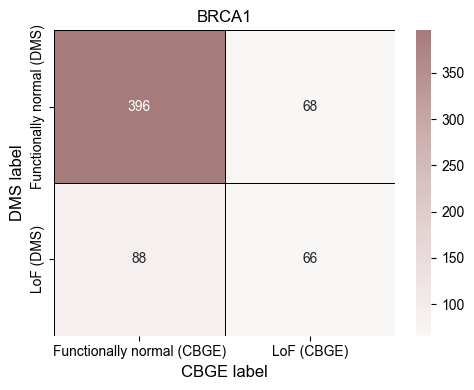

In [10]:
from matplotlib.colors import LinearSegmentedColormap

df_merged = df_dms[['Identifier_prot', 'label']].merge(
    df_cri[['Identifier_prot', 'label']],
    on='Identifier_prot',
    suffixes=('_dms', '_cri')
)

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

labels_dms = df_merged['label_dms']
labels_cri = df_merged['label_cri']

concordance = (labels_dms == labels_cri).sum()
discordance = (labels_dms != labels_cri).sum()

print(f"Total variants: {len(df_merged)}")
print(f"Concordant: {concordance} ({concordance/len(df_merged)*100:.1f}%)")
print(f"Discordant: {discordance} ({discordance/len(df_merged)*100:.1f}%)")
print()

dms_normal_cri_lof = ((labels_dms == 0) & (labels_cri == 1)).sum()
dms_lof_cri_normal = ((labels_dms == 1) & (labels_cri == 0)).sum()
print(f"DMS Normal → CBGE LoF: {dms_normal_cri_lof}")
print(f"DMS LoF → CBGE Normal: {dms_lof_cri_normal}")

fig, ax = plt.subplots(figsize=(5, 4))

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

cm = confusion_matrix(labels_dms, labels_cri)

morandi_hex = ['#F9F6F6', '#E4D4D4', '#CBAEAE', '#A57B7B']
morandi_cmap = LinearSegmentedColormap.from_list('morandi_blue', morandi_hex)

sns.heatmap(cm, annot=True, fmt='d', cmap=morandi_cmap,
            xticklabels=['Functionally normal (CBGE)', 'LoF (CBGE)'],
            yticklabels=['Functionally normal (DMS)', 'LoF (DMS)'],
            ax=ax, linewidths=0.5, linecolor='black')

ax.set_xlabel('CBGE label', fontsize=12)
ax.set_ylabel('DMS label', fontsize=12)
ax.set_title('BRCA1')

plt.tight_layout()
plt.show()

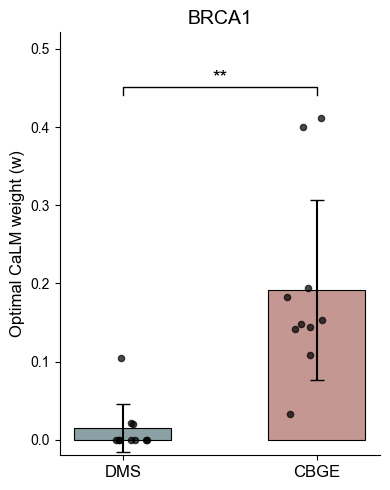


Summary:
BRCA1 DMS:  w = 0.015 ± 0.031
BRCA1 CBGE: w = 0.192 ± 0.115
Fold increase: 13.2x
Wilcoxon p = 0.0020


In [11]:
import matplotlib.pyplot as plt
import numpy as np

conditions = ['DMS', 'CBGE']
brca1_means = [np.mean(dms_weights), np.mean(cri_weights)]
brca1_stds = [np.std(dms_weights), np.std(cri_weights)]

fig, ax = plt.subplots(1, 1, figsize=(4, 5))

x = np.array([0, 1])
bars = ax.bar(x, brca1_means, width=0.5, color=['#8CA1A5', '#C49792'],
              edgecolor='black', linewidth=0.8, zorder=2)

ax.errorbar(x, brca1_means, yerr=brca1_stds, fmt='none',
            color='black', capsize=5, linewidth=1.5, zorder=3)

np.random.seed(42)
jitter = 0.08
for i, weights in enumerate([dms_weights, cri_weights]):
    x_points = np.random.normal(x[i], jitter, size=len(weights))
    ax.scatter(x_points, weights, color='black', s=20, alpha=0.7, zorder=4)

y_max = max(brca1_means[1] + brca1_stds[1], max(cri_weights)) + 0.03
ax.plot([0, 0, 1, 1], [y_max, y_max + 0.01, y_max + 0.01, y_max],
        color='black', linewidth=1)
ax.text(0.5, y_max + 0.015, '**', ha='center', fontsize=14)

ax.set_xticks(x)
ax.set_xticklabels(conditions, fontsize=12)
ax.set_ylabel('Optimal CaLM weight (w)', fontsize=12)
ax.set_title('BRCA1', fontsize=14)
ax.set_ylim(-0.02, y_max + 0.08)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f"\nSummary:")
print(f"BRCA1 DMS:  w = {brca1_means[0]:.3f} ± {brca1_stds[0]:.3f}")
print(f"BRCA1 CBGE: w = {brca1_means[1]:.3f} ± {brca1_stds[1]:.3f}")
print(f"Fold increase: {brca1_means[1]/brca1_means[0]:.1f}x")
print(f"Wilcoxon p = {p_brca1:.4f}")

## TP53

In [12]:
(normal_prot_cri, normal_gene_cri,
 lof_prot_cri, lof_gene_cri,
 normal_prot_dms, normal_gene_dms,
 lof_prot_dms, lof_gene_dms) = load_gene_data('tp53')

In [13]:
normal_prot_dms = add_suffix(normal_prot_dms, 'prot')
normal_gene_dms = add_suffix(normal_gene_dms, 'gene')
lof_prot_dms = add_suffix(lof_prot_dms, 'prot')
lof_gene_dms = add_suffix(lof_gene_dms, 'gene')
normal_prot_cri = add_suffix(normal_prot_cri, 'prot')
normal_gene_cri = add_suffix(normal_gene_cri, 'gene')
lof_prot_cri = add_suffix(lof_prot_cri, 'prot')
lof_gene_cri = add_suffix(lof_gene_cri, 'gene')

In [14]:
df_dms = prepare_matched_data(normal_prot_dms, normal_gene_dms, lof_prot_dms, lof_gene_dms)
df_cri = prepare_matched_data(normal_prot_cri, normal_gene_cri, lof_prot_cri, lof_gene_cri)

print(f"DMS: {len(df_dms)} variants (Normal: {(df_dms['label']==0).sum()}, LoF: {(df_dms['label']==1).sum()})")
print(f"CBGE: {len(df_cri)} variants (Normal: {(df_cri['label']==0).sum()}, LoF: {(df_cri['label']==1).sum()})")

dms_weights, dms_aucs = optimize_weight(df_dms)
cri_weights, cri_aucs = optimize_weight(df_cri)

print(f"\nDMS: w = {np.mean(dms_weights):.3f} ± {np.std(dms_weights):.3f}")
print(f"CBGE: w = {np.mean(cri_weights):.3f} ± {np.std(cri_weights):.3f}")

from scipy.stats import wilcoxon
stat, p = wilcoxon(cri_weights, dms_weights)
print(f"\nDMS vs CBGE weights, p = {p:.4f}")

DMS: 1195 variants (Normal: 769, LoF: 426)
CBGE: 1195 variants (Normal: 594, LoF: 601)

DMS: w = 0.000 ± 0.000
CBGE: w = 0.017 ± 0.008

DMS vs CBGE weights, p = 0.0039


Total variants: 1195
Concordant: 928 (77.7%)
Discordant: 267 (22.3%)

DMS Normal → CBGE LoF: 221
DMS LoF → CBGE Normal: 46


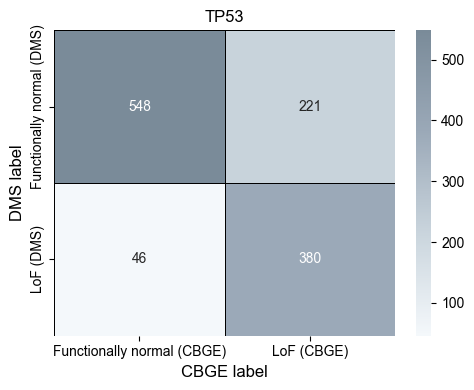

In [15]:
df_merged = df_dms[['Identifier_prot', 'label']].merge(
    df_cri[['Identifier_prot', 'label']],
    on='Identifier_prot',
    suffixes=('_dms', '_cri')
)

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

labels_dms = df_merged['label_dms']
labels_cri = df_merged['label_cri']

concordance = (labels_dms == labels_cri).sum()
discordance = (labels_dms != labels_cri).sum()

print(f"Total variants: {len(df_merged)}")
print(f"Concordant: {concordance} ({concordance/len(df_merged)*100:.1f}%)")
print(f"Discordant: {discordance} ({discordance/len(df_merged)*100:.1f}%)")
print()

dms_normal_cri_lof = ((labels_dms == 0) & (labels_cri == 1)).sum()
dms_lof_cri_normal = ((labels_dms == 1) & (labels_cri == 0)).sum()
print(f"DMS Normal → CBGE LoF: {dms_normal_cri_lof}")
print(f"DMS LoF → CBGE Normal: {dms_lof_cri_normal}")

fig, ax = plt.subplots(figsize=(5, 4))

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

morandi_hex = ['#F4F8FB', '#CAD5DD', '#9BA9B8', '#7A8B99']
morandi_cmap = LinearSegmentedColormap.from_list('morandi_blue', morandi_hex)

cm = confusion_matrix(labels_dms, labels_cri)
sns.heatmap(cm, annot=True, fmt='d', cmap=morandi_cmap,
            xticklabels=['Functionally normal (CBGE)', 'LoF (CBGE)'],
            yticklabels=['Functionally normal (DMS)', 'LoF (DMS)'],
            ax=ax, linewidths=0.5, linecolor='black')

ax.set_xlabel('CBGE label', fontsize=12)
ax.set_ylabel('DMS label', fontsize=12)
ax.set_title('TP53')

plt.tight_layout()
plt.show()

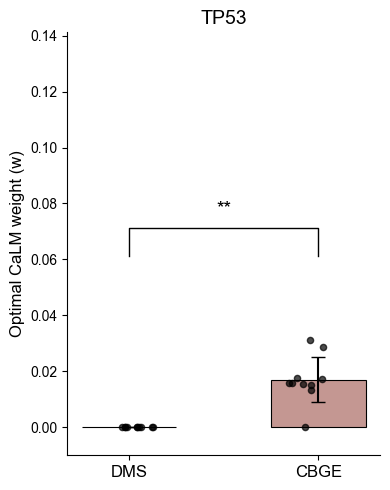


Summary:
TP53 DMS:  w = 0.000 ± 0.000
TP53 CBGE: w = 0.017 ± 0.008
Fold increase: infx
Wilcoxon p = 0.0039


In [16]:
import matplotlib.pyplot as plt
import numpy as np

conditions = ['DMS', 'CBGE']
tp53_means = [np.mean(dms_weights), np.mean(cri_weights)]
tp53_stds = [np.std(dms_weights), np.std(cri_weights)]

fig, ax = plt.subplots(1, 1, figsize=(4, 5))

x = np.array([0, 1])
bars = ax.bar(x, tp53_means, width=0.5, color=['#8CA1A5', '#C49792'],
              edgecolor='black', linewidth=0.8, zorder=2)

ax.errorbar(x, tp53_means, yerr=tp53_stds, fmt='none',
            color='black', capsize=5, linewidth=1.5, zorder=3)

np.random.seed(42)
jitter = 0.08
for i, weights in enumerate([dms_weights, cri_weights]):
    x_points = np.random.normal(x[i], jitter, size=len(weights))
    ax.scatter(x_points, weights, color='black', s=20, alpha=0.7, zorder=4)

y_max = max(tp53_means[1] + tp53_stds[1], max(cri_weights)) + 0.03
ax.plot([0, 0, 1, 1], [y_max, y_max + 0.01, y_max + 0.01, y_max],
        color='black', linewidth=1)
ax.text(0.5, y_max + 0.015, '**', ha='center', fontsize=14)

ax.set_xticks(x)
ax.set_xticklabels(conditions, fontsize=12)
ax.set_ylabel('Optimal CaLM weight (w)', fontsize=12)
ax.set_title('TP53', fontsize=14)
ax.set_ylim(-0.01, y_max + 0.08)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f"\nSummary:")
print(f"TP53 DMS:  w = {tp53_means[0]:.3f} ± {tp53_stds[0]:.3f}")
print(f"TP53 CBGE: w = {tp53_means[1]:.3f} ± {tp53_stds[1]:.3f}")
print(f"Fold increase: {tp53_means[1]/tp53_means[0]:.1f}x")
print(f"Wilcoxon p = {p:.4f}")